<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=300807538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [4]:
import os
import sys
import importlib

# 1. Nettoyage et téléchargement du nouveau pipeline
# Remplace par l'URL de ta branche où tu vas pousser le nouveau data_pipeline.py
GITHUB_RAW_URL = "https://raw.githubusercontent.com/wekt2k04/NeuroSight_AI/main/notebooks/data_pipeline.py"

print("📥 Mise à jour du pipeline NeuroSight...")
!wget -q -O data_pipeline.py {GITHUB_RAW_URL}

if '/kaggle/working' not in sys.path:
    sys.path.append('/kaggle/working')

# 2. Importation dynamique
try:
    import data_pipeline
    importlib.reload(data_pipeline)
    from data_pipeline import prepare_data, show_sample_batch, plot_class_distribution
    print("✅ Pipeline 'Feature Engineered' chargé avec succès.")
except Exception as e:
    print(f"❌ Erreur d'import : {e}")

📥 Mise à jour du pipeline NeuroSight...
✅ Pipeline 'Feature Engineered' chargé avec succès.


In [5]:
# --- CONFIGURATION DES CHEMINS ---
# Assure-toi que ces chemins correspondent à tes inputs Kaggle
CSV_PATH = '/kaggle/input/datasets/wilfriedtsetse04/mon-csv-officiel/oasis_cross-sectional-5708aa0a98d82080.xlsx'
IMAGES_DIR = '/kaggle/input/datasets/ninadaithal/imagesoasis/Data'

# --- CRÉATION DES LOADERS ---
# Note : on utilise la nouvelle fonction 'prepare_data'
train_loader, val_loader, classes = prepare_data(
    csv_path=CSV_PATH, 
    images_dir=IMAGES_DIR, 
    batch_size=32
)

# # --- AUDIT VISUEL ---
# print(f"\n🚀 Classes prêtes : {classes}")
# plot_class_distribution(train_loader, classes)
# show_sample_batch(train_loader, classes)

📖 1. Chargement des données cliniques et Imputation MICE...
   ✅ Imputation des valeurs manquantes terminée (MICE).
🔍 2. Scan du dossier d'images : /kaggle/input/datasets/ninadaithal/imagesoasis/Data
   ✅ 47580 images valides associées avec succès.

🛡️ 3. Application du Group Split par ID Patient (Validation: 20.0%)...
   📊 Patients uniques Train : 160
   📊 Patients uniques Val   : 40
   🚨 Chevauchement (Leakage): 0 patients (Doit être 0).

⚖️ 4. Calcul des poids pour l'équilibrage des classes (WeightedRandomSampler)...
🚀 Pipeline prêt ! Les DataLoaders vont générer des lots (Images, Labels).


🖥️ Calcul sur : cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 



🚀 Lancement de l'entraînement (Fine-Tuning complet)...
Époque 1/10
---------------
Train Loss: 0.4216 | Acc: 0.8293
Val   Loss: 1.3795 | Acc: 0.5880
Époque 2/10
---------------
Train Loss: 0.0907 | Acc: 0.9684
Val   Loss: 1.6588 | Acc: 0.6039
Époque 3/10
---------------
Train Loss: 0.0467 | Acc: 0.9839
Val   Loss: 1.9778 | Acc: 0.6147
Époque 4/10
---------------
Train Loss: 0.0338 | Acc: 0.9889
Val   Loss: 1.9570 | Acc: 0.6034
Époque 5/10
---------------
Train Loss: 0.0146 | Acc: 0.9953
Val   Loss: 2.0216 | Acc: 0.6411
Époque 6/10
---------------
Train Loss: 0.0107 | Acc: 0.9967
Val   Loss: 2.0024 | Acc: 0.6656
Époque 7/10
---------------
Train Loss: 0.0088 | Acc: 0.9973
Val   Loss: 1.9931 | Acc: 0.6281
Époque 8/10
---------------
Train Loss: 0.0070 | Acc: 0.9977
Val   Loss: 2.2362 | Acc: 0.6463
Époque 9/10
---------------
Train Loss: 0.0051 | Acc: 0.9984
Val   Loss: 2.2566 | Acc: 0.6412
Époque 10/10
---------------
Train Loss: 0.0037 | Acc: 0.9989
Val   Loss: 2.1710 | Acc: 0.6631

🎉 

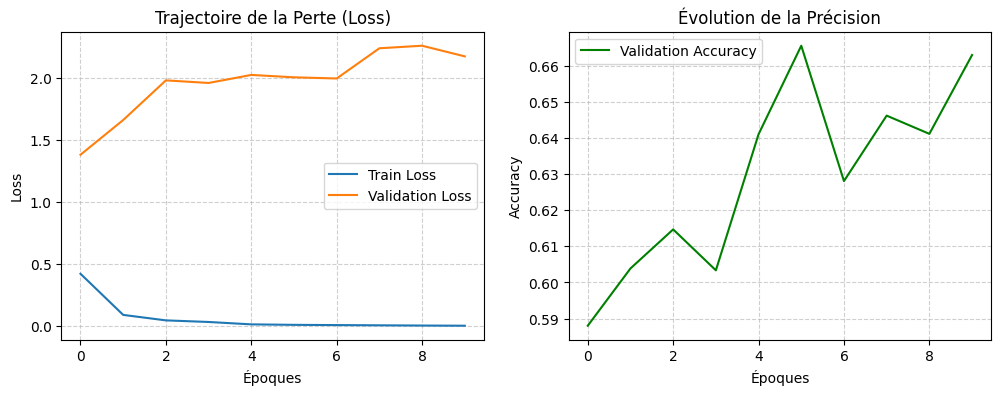

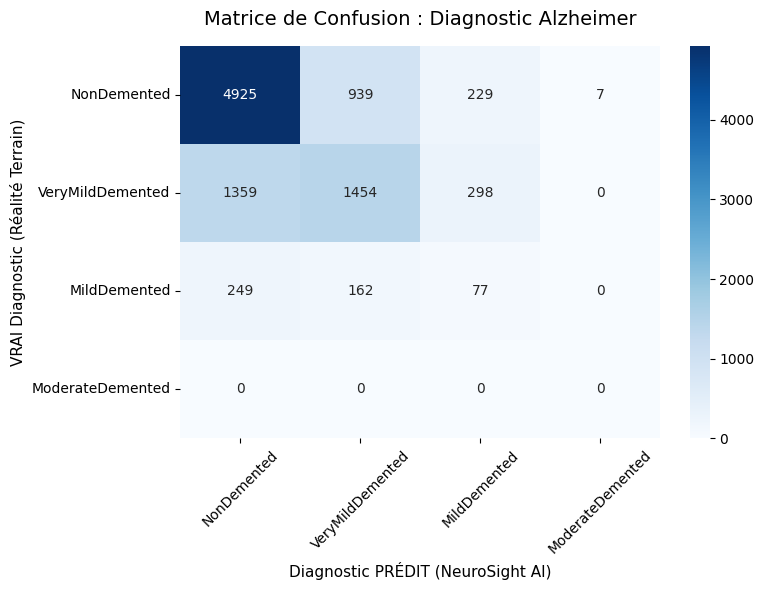

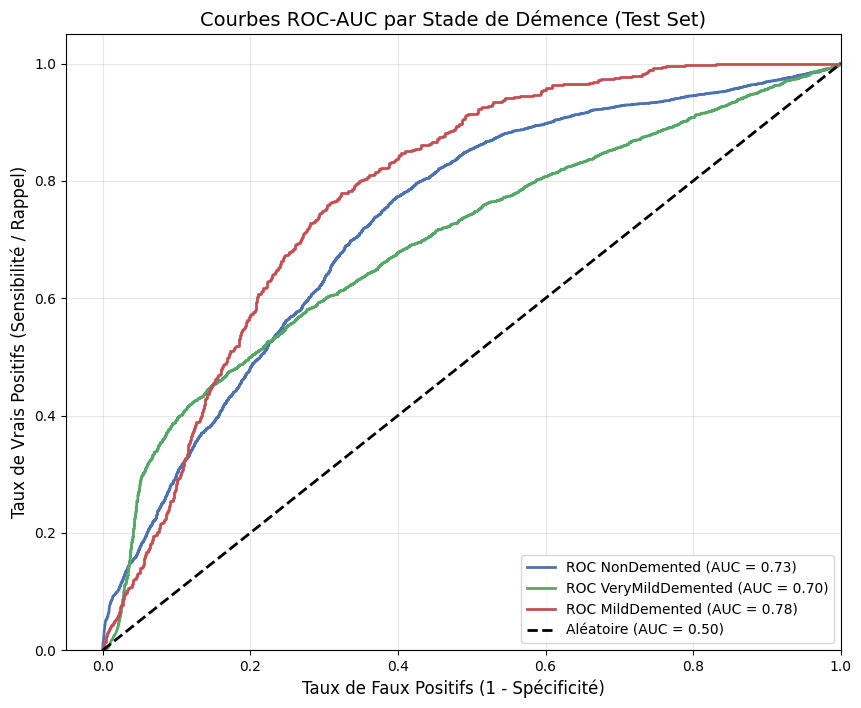

In [6]:
# ==========================================================
# CELLULE 3 : ENTRAÎNEMENT & AUDIT DES MÉTRIQUES (SEMAINE 2)
# ==========================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy

# 1. CONFIGURATION DU MODÈLE HYPER-PARAMÉTRÉ
# ----------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Calcul sur : {device}")

def build_neurosight_model(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    num_ftrs = model.classifier[1].in_features
    # Remplacement de la tête de classification
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True), # Prévention du sur-apprentissage
        nn.Linear(num_ftrs, num_classes)
    )
    return model.to(device)

model = build_neurosight_model(len(classes))

# 2. MOTEUR D'ENTRAÎNEMENT AVEC TRACKING
# ----------------------------------------------------------
def train_model(model, train_loader, val_loader, num_epochs=15):
    criterion = nn.CrossEntropyLoss()
    # Optimiseur moderne avec Weight Decay (Régularisation)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    print("\n🚀 Lancement de l'entraînement (Fine-Tuning complet)...")
    for epoch in range(num_epochs):
        print(f"Époque {epoch+1}/{num_epochs}")
        print("-" * 15)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                print(f"Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                print(f"Val   Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
                scheduler.step(epoch_loss)
                
                # Sauvegarde du meilleur modèle
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

    print(f"\n🎉 Entraînement terminé. Meilleure Accuracy de validation : {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history

# --- LANCEMENT DE L'ENTRAÎNEMENT ---
# (On met 10 époques pour tester, tu pourras augmenter à 25+ plus tard)
best_model, training_history = train_model(model, train_loader, val_loader, num_epochs=10)

# 3. ÉVALUATION ET VISUALISATION DES MÉTRIQUES AVANCÉES
# ----------------------------------------------------------
def evaluate_and_plot(model, val_loader, class_names, history):
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            # Probabilités pour ROC-AUC
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_probs = np.array(y_probs)
    
    # --- A. Rapport Clinique ---
    print("\n📋 RAPPORT DE PERFORMANCE MÉDICALE")
    print("Ce rapport privilégie le 'Recall' (Sensibilité) : on veut rater le moins de malades possible.")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # --- B. Courbes d'Apprentissage (Overfitting Check) ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Trajectoire de la Perte (Loss)')
    plt.xlabel('Époques')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc'], label='Validation Accuracy', color='green')
    plt.title('Évolution de la Précision')
    plt.xlabel('Époques')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # --- C. Matrice de Confusion Clinique ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Matrice de Confusion : Diagnostic Alzheimer', fontsize=14, pad=15)
    plt.ylabel('VRAI Diagnostic (Réalité Terrain)', fontsize=11)
    plt.xlabel('Diagnostic PRÉDIT (NeuroSight AI)', fontsize=11)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # --- D. Courbes ROC-AUC (Le juge de paix) ---
    # Binarisation des labels pour le multiclasse (One-vs-Rest)
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    
    plt.figure(figsize=(10, 8))
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
    
    for i in range(len(class_names)):
        # Vérification si la classe est présente dans les tests pour éviter les erreurs
        if np.sum(y_true_bin[:, i]) > 0:
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'ROC {class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC = 0.50)')
    plt.xlim([-0.05, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=12)
    plt.ylabel('Taux de Vrais Positifs (Sensibilité / Rappel)', fontsize=12)
    plt.title('Courbes ROC-AUC par Stade de Démence (Test Set)', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# --- GÉNÉRATION DU RAPPORT VISUEL ---
evaluate_and_plot(best_model, val_loader, classes, training_history)